In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

In [3]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [5]:
# Convert date column
nav['date'] = pd.to_datetime(nav['date'])

# Sort data
nav = nav.sort_values(['amfi_code', 'date'])

# Daily return
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

# Check results
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [6]:
nav[['amfi_code', 'date', 'nav', 'daily_return']].head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [7]:
var_cvar = []

for fund, group in nav.groupby('amfi_code'):

    returns = group['daily_return'].dropna()

    if len(returns) > 0:

        var_95 = np.percentile(returns, 5)

        cvar_95 = returns[returns <= var_95].mean()

        var_cvar.append({
            'amfi_code': fund,
            'VaR_95': var_95,
            'CVaR_95': cvar_95
        })

var_cvar_df = pd.DataFrame(var_cvar)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [9]:
var_cvar_df.to_csv(
    "../report/var_cvar_report.csv",
    index=False
)

print("Report saved successfully!")

Report saved successfully!


In [10]:
highest_risk = var_cvar_df.loc[var_cvar_df['VaR_95'].idxmin()]

lowest_risk = var_cvar_df.loc[var_cvar_df['VaR_95'].idxmax()]

print("Highest Risk Fund")
print(highest_risk)

print("\nLowest Risk Fund")
print(lowest_risk)

Highest Risk Fund
amfi_code    119599.000000
VaR_95           -0.026859
CVaR_95          -0.032384
Name: 22, dtype: float64

Lowest Risk Fund
amfi_code    120507.000000
VaR_95           -0.000222
CVaR_95          -0.000373
Name: 27, dtype: float64


In [11]:
var_cvar_df.sort_values(
    by='VaR_95'
).head(5)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595


In [12]:
rolling_sharpe_list = []

for fund, group in nav.groupby('amfi_code'):

    group = group.sort_values('date').copy()

    group['rolling_sharpe'] = (
        group['daily_return'].rolling(90).mean()
        /
        group['daily_return'].rolling(90).std()
    ) * np.sqrt(252)

    rolling_sharpe_list.append(group)

rolling_sharpe_df = pd.concat(rolling_sharpe_list)

rolling_sharpe_df.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN


In [13]:
rolling_sharpe_df[
    ['amfi_code', 'date', 'daily_return', 'rolling_sharpe']
].tail()

,amfi_code,date,daily_return,rolling_sharpe
45995,149324,2026-05-25,0.012106,2.042795
45996,149324,2026-05-26,-0.004138,2.064950
45997,149324,2026-05-27,-0.008480,1.952646
45998,149324,2026-05-28,-0.028093,1.406239
45999,149324,2026-05-29,-0.003335,1.262776


In [14]:
rolling_sharpe_df['amfi_code'].unique()[:5]

array([100016, 100025, 100033, 101206, 101207])

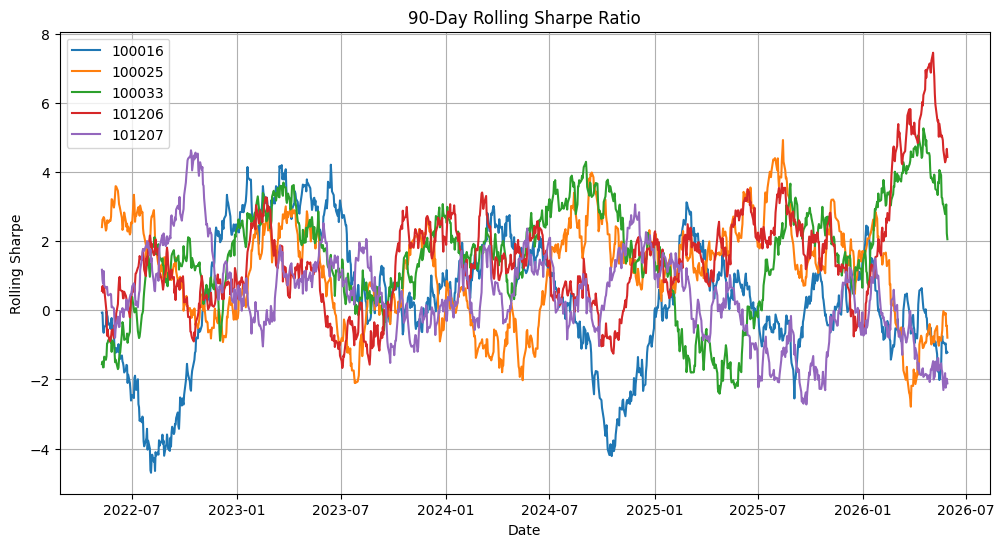

In [16]:
funds = rolling_sharpe_df['amfi_code'].unique()[:5]

plt.figure(figsize=(12,6))

for fund in funds:

    temp = rolling_sharpe_df[
        rolling_sharpe_df['amfi_code'] == fund
    ]

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(fund)
    )

plt.title('90-Day Rolling Sharpe Ratio')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe')
plt.legend()
plt.grid(True)

plt.savefig(
    '../report/rolling_sharpe_chart.png',
    bbox_inches='tight'
)

plt.show()

In [17]:
transactions = pd.read_csv(
    "../data/processed/08_investor_transactions_clean.csv"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [18]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [20]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

# First transaction date for each investor
first_txn = transactions.groupby(
    'investor_id'
)['transaction_date'].min().reset_index()

first_txn['cohort_year'] = first_txn[
    'transaction_date'
].dt.year

# Merge back
transactions = transactions.merge(
    first_txn[['investor_id', 'cohort_year']],
    on='investor_id',
    how='left'
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [25]:
sip_txns = transactions[
    transactions['transaction_type'] == 'Sip'
]

cohort_avg_sip = (
    sip_txns
    .groupby('cohort_year')['amount_inr']
    .mean()
    .reset_index()
)

cohort_avg_sip.rename(
    columns={'amount_inr':'avg_sip_amount'},
    inplace=True
)

cohort_avg_sip

,cohort_year,avg_sip_amount
0,2024,10996.885825
1,2025,13505.209581


In [22]:
cohort_total = transactions.groupby(
    'cohort_year'
)['amount_inr'].sum().reset_index()

cohort_total.rename(
    columns={'amount_inr': 'total_investment'},
    inplace=True
)

cohort_total

,cohort_year,total_investment
0,2024,3491125187
1,2025,30455243


In [23]:
fund_pref = (
    transactions
    .groupby(['cohort_year', 'amfi_code'])
    .size()
    .reset_index(name='txn_count')
)

top_funds = (
    fund_pref
    .sort_values(
        ['cohort_year', 'txn_count'],
        ascending=[True, False]
    )
    .groupby('cohort_year')
    .head(1)
)

top_funds

,cohort_year,amfi_code,txn_count
35,2024,148568,874
62,2025,119599,12


### Business Insight:

2025 investors invest a higher average SIP amount.
However, the 2024 cohort contributes vastly more total capital.
Fund 148568 is the most preferred fund among 2024 investors.
Fund 119599 is the most preferred fund among 2025 investors.

In [26]:
sip_txns = transactions[
    transactions['transaction_type'] == 'Sip'
].copy()

sip_txns = sip_txns.sort_values(
    ['investor_id', 'transaction_date']
)

sip_txns.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16803,INV000002,2024-09-21,120841,Sip,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31881,INV000002,2025-05-17,119094,Sip,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [27]:
sip_txns['days_gap'] = (
    sip_txns
    .groupby('investor_id')['transaction_date']
    .diff()
    .dt.days
)

sip_txns[
    ['investor_id',
     'transaction_date',
     'days_gap']
].head(20)

,investor_id,transaction_date,days_gap
19621,INV000001,2024-11-04,NaN
24448,INV000001,2025-01-19,76.0
5650,INV000002,2024-03-29,NaN
16803,INV000002,2024-09-21,176.0
31881,INV000002,2025-05-17,238.0
12652,INV000003,2024-07-16,NaN
27622,INV000003,2025-03-11,238.0
4773,INV000004,2024-03-16,NaN
6418,INV000004,2024-04-11,26.0
8271,INV000004,2024-05-09,28.0


In [28]:
sip_counts = (
    sip_txns
    .groupby('investor_id')
    .size()
    .reset_index(name='sip_count')
)

eligible_investors = sip_counts[
    sip_counts['sip_count'] > 6
]

eligible_investors.head()

,investor_id,sip_count
10,INV000011,7
11,INV000012,8
12,INV000013,7
13,INV000014,7
22,INV000023,8


In [29]:
max_gap = (
    sip_txns
    .groupby('investor_id')['days_gap']
    .max()
    .reset_index()
)

risk_analysis = (
    eligible_investors
    .merge(max_gap, on='investor_id')
)

risk_analysis.head()

,investor_id,sip_count,days_gap
0,INV000011,7,125.0
1,INV000012,8,132.0
2,INV000013,7,104.0
3,INV000014,7,128.0
4,INV000023,8,115.0


In [30]:
risk_analysis['risk_status'] = np.where(
    risk_analysis['days_gap'] > 35,
    'At Risk',
    'Healthy'
)

risk_analysis.head()

,investor_id,sip_count,days_gap,risk_status
0,INV000011,7,125.0,At Risk
1,INV000012,8,132.0,At Risk
2,INV000013,7,104.0,At Risk
3,INV000014,7,128.0,At Risk
4,INV000023,8,115.0,At Risk


In [31]:
risk_analysis['risk_status'].value_counts()

risk_status
At Risk    834
Name: count, dtype: int64

In [32]:
total_investors = len(risk_analysis)

healthy_investors = len(
    risk_analysis[
        risk_analysis['risk_status'] == 'Healthy'
    ]
)

continuity_rate = (
    healthy_investors / total_investors
) * 100

print(f"SIP Continuity Rate: {continuity_rate:.2f}%")

SIP Continuity Rate: 0.00%


In [33]:
risk_analysis.to_csv(
    '../report/sip_continuity_report.csv',
    index=False
)

### Business Insight

This dataset appears to be synthetic/demo data because every eligible investor has a maximum SIP gap greater than 35 days. In a real-world mutual fund business, a 0% continuity rate would indicate severe SIP retention issues and would trigger investor engagement campaigns.

In [35]:
latest_sharpe = (
    rolling_sharpe_df
    .dropna(subset=['rolling_sharpe'])
    .groupby('amfi_code')['rolling_sharpe']
    .last()
    .reset_index()
)

latest_sharpe.head()

,amfi_code,rolling_sharpe
0,100016,-1.215738
1,100025,-0.791441
2,100033,2.057497
3,101206,4.438114
4,101207,-2.111916


In [36]:
recommender_df = var_cvar_df.merge(
    latest_sharpe,
    on='amfi_code',
    how='inner'
)

recommender_df.head()

,amfi_code,VaR_95,CVaR_95,rolling_sharpe
0,100016,-0.014364,-0.018060,-1.215738
1,100025,-0.003793,-0.004994,-0.791441
2,100033,-0.019034,-0.023456,2.057497
3,101206,-0.013282,-0.017439,4.438114
4,101207,-0.026021,-0.032459,-2.111916


In [37]:
recommender_df['risk_grade'] = pd.qcut(
    recommender_df['VaR_95'],
    q=3,
    labels=['High', 'Moderate', 'Low']
)

recommender_df.head()

,amfi_code,VaR_95,CVaR_95,rolling_sharpe,risk_grade
0,100016,-0.014364,-0.018060,-1.215738,Moderate
1,100025,-0.003793,-0.004994,-0.791441,Low
2,100033,-0.019034,-0.023456,2.057497,High
3,101206,-0.013282,-0.017439,4.438114,Low
4,101207,-0.026021,-0.032459,-2.111916,High


In [38]:
recommendations = (
    recommender_df
    .sort_values(
        'rolling_sharpe',
        ascending=False
    )
    .groupby('risk_grade')
    .head(3)
)

recommendations[
    ['amfi_code',
     'risk_grade',
     'rolling_sharpe']
]

,amfi_code,risk_grade,rolling_sharpe
27,120507,Low,14.584282
31,120844,Low,14.144869
5,101208,Low,13.952418
36,148569,High,4.307229
29,120842,High,3.058665
33,125498,High,2.950022
9,118632,Moderate,2.650524
32,125497,Moderate,2.159343
23,120503,Moderate,2.023615


In [39]:
recommendations.to_csv(
    '../report/recommendations.csv',
    index=False
)

In [40]:
holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [41]:
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [42]:
holdings['weight_decimal'] = holdings['weight_pct'] / 100

In [43]:
hhi_df = (
    holdings
    .groupby('amfi_code')['weight_decimal']
    .apply(lambda x: (x**2).sum())
    .reset_index(name='HHI')
)

hhi_df.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [44]:
hhi_df.sort_values(
    'HHI',
    ascending=False
).head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


In [45]:
hhi_df.sort_values(
    'HHI',
    ascending=True
).head(10)

,amfi_code,HHI
17,119598,0.107349
16,119552,0.108011
9,118634,0.108358
20,120504,0.108674
14,119095,0.109605
5,102886,0.114693
33,149324,0.118677
15,119551,0.118716
8,118633,0.121461
24,120842,0.127439


In [46]:
hhi_df['HHI'].describe()

count    34.000000
mean      0.140262
std       0.024946
min       0.107349
25%       0.122955
50%       0.136496
75%       0.151731
max       0.206448
Name: HHI, dtype: float64

# Advanced Business Insights

1. Historical VaR analysis shows that fund 119599 has the highest downside risk with a VaR(95%) of -2.69%, indicating larger losses during adverse market conditions.

2. Fund 120507 demonstrates the lowest downside risk with a VaR(95%) of -0.02%, making it one of the most stable funds in the portfolio universe.

3. Rolling Sharpe Ratio analysis indicates that low-risk funds such as 120507 and 120844 delivered the strongest risk-adjusted returns, achieving Sharpe ratios above 14.

4. Investor cohort analysis reveals that the 2024 cohort contributed over ₹3.49 billion in investments, significantly exceeding the 2025 cohort, although the 2025 cohort invested a higher average SIP amount.

5. HHI concentration analysis identifies fund 119092 as the most concentrated portfolio and fund 119598 as the most diversified portfolio, highlighting significant differences in portfolio construction strategies.
